In [1]:
import pandas as pd
d=pd.read_csv("Food_Delivery_Times.csv")
d=d.head(1000)
d

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [2]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [3]:
d1=d.select_dtypes(["int64","float64"])
d1

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,12,1.0,43
1,738,16.42,20,2.0,84
2,741,9.52,28,1.0,59
3,661,7.44,5,1.0,37
4,412,19.03,16,5.0,68
...,...,...,...,...,...
995,107,8.50,13,3.0,54
996,271,16.28,8,9.0,71
997,861,15.62,26,2.0,81
998,436,14.17,8,0.0,55


In [7]:
d1.corr()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
Order_ID,1.000000,-0.024483,-0.035100,0.013152,-0.036650
Distance_km,-0.024483,1.000000,-0.009037,-0.007842,0.780998
Preparation_Time_min,-0.035100,-0.009037,1.000000,-0.030830,0.307350
Courier_Experience_yrs,0.013152,-0.007842,-0.030830,1.000000,-0.090433
Delivery_Time_min,-0.036650,0.780998,0.307350,-0.090433,1.000000


In [8]:
x=d1[["Distance_km","Preparation_Time_min"]]
y=d1["Delivery_Time_min"]

In [9]:
d1.kurt()

Order_ID                 -1.200000
Distance_km              -1.229247
Preparation_Time_min     -1.236928
Courier_Experience_yrs   -1.266011
Delivery_Time_min         0.291338
dtype: float64

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.2,random_state=42)

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
y_pre=lr.predict(x_test)
y_pre

array([41.53406931, 66.35070592, 35.68735633, 44.39163024, 84.63542773,
       37.79712714, 64.08728239, 28.2560071 , 27.22057546, 67.13179862,
       72.63349747, 65.29321268, 34.55564456, 68.45286337, 89.33999756,
       88.49592732, 32.67092698, 73.21198779, 41.00051179, 60.38565122,
       83.8928533 , 29.00499606, 74.29316183, 74.47208342, 50.91272442,
       32.91564414, 74.22736626, 28.5416402 , 48.57106551, 61.93377762,
       56.83164749, 21.32892968, 59.10430358, 40.45169644, 71.99763455,
       20.27143643, 70.00098977, 54.29742834, 47.73101212, 67.94658314,
       74.41791808, 40.16405491, 74.81508913, 69.92356399, 35.90800346,
       22.83814856, 83.56228741, 89.55863626, 83.3091473 , 35.73750482,
       55.24098597, 61.55708009, 43.49300541, 74.86964372, 54.94812875,
       55.10579833, 71.62093702, 72.15329571, 61.99555633, 90.89214082,
       52.73284527, 41.91679212, 41.36878636, 51.69822322, 51.44628194,
       60.54371005, 71.96834882, 85.27650635, 58.75287492, 48.91

In [18]:
y_test

521     32
737     68
740     39
660     44
411     85
      ... 
619    105
855     72
803     60
645    101
846     49
Name: Delivery_Time_min, Length: 800, dtype: int64

In [19]:
from sklearn.metrics import r2_score

In [20]:
r2_score(y_test,y_pre)

0.6954841704368084

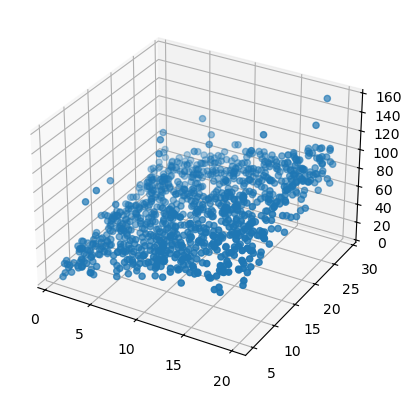

In [27]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
figure=plt.figure()
ax=figure.add_subplot(111,projection="3d")
ax.scatter(x["Distance_km"],x["Preparation_Time_min"],y)
plt.show()